Example usage of DBEM.py

Includes a verification problem for time-dependent heat diffusion in a 2-D annulus, and a demo of a random distribution of magma chambers represented as circular holes cut out from a 2-D disk.

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import cnetwork

In [3]:
import DBEM

Initial condition is the 1st eigenfunction in the annulus.
Top curve is the initial condition; different curves show advancing time (t).
Dotted line shows the steady-state solution.


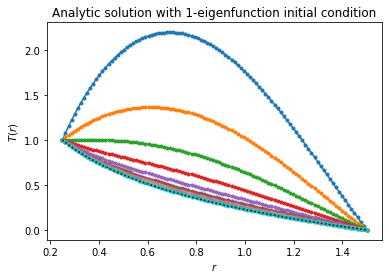

In [4]:
a = 0.25
b = 1.5
t_final = 1.0
for t in np.linspace(0, t_final, 10):
  r_test_range = np.linspace(a, b, 100)
  T_test = DBEM.annulus_steady_term(r_test_range, t, a, b) + DBEM.annulus_series_term(r_test_range, t, a, b, 1)
  plt.plot(r_test_range, T_test, '.-')

plt.plot(r_test_range, DBEM.annulus_steady_term(r_test_range, t, a, b), 'k:')
plt.title("Analytic solution with 1-eigenfunction initial condition")
plt.xlabel("$r$")
plt.ylabel("$T(r)$")
print("Initial condition is the 1st eigenfunction in the annulus.")
print("Top curve is the initial condition; different curves show advancing time (t).")
print("Dotted line shows the steady-state solution.")


At each timestep, the algebraic equation being solved is 
  LU == f
where U is the vector containing du/dn and u at the timestep k,
and f == B(du/dn) + FU_{k-1}.
Left two plots: sparsity pattern of the matrix L
Third plot: sparsity pattern of B, mapping boundary data to RHS.
Fourth plot: sparsity pattern of F, mapping U_{k-1} data to RHS.
Note the LHS matrix and mappings from previous timestep are dense


(array([[-1.01921299e-01, -5.27709931e-02, -3.40736675e-02, ...,
         -6.07811089e-03,  8.14581617e-02,  7.76459641e-02],
        [-5.27709931e-02, -1.01921299e-01, -5.27709928e-02, ...,
         -3.49919101e-02,  1.25211561e-01,  1.25843489e-01],
        [-3.40736677e-02, -5.27709931e-02, -1.01921298e-01, ...,
         -5.37584107e-02,  2.03008763e-01,  1.97318459e-01],
        ...,
        [ 1.01058909e-03,  5.81799890e-03,  8.93824805e-03, ...,
          1.55735387e+00, -7.03352615e-02, -7.43984995e-02],
        [-1.60211908e-02, -2.46266090e-02, -3.99277621e-02, ...,
         -8.32007629e-02,  1.48392162e+00,  3.58355534e-01],
        [-1.52561882e-02, -2.47262297e-02, -3.87699162e-02, ...,
         -8.79195268e-02,  3.57998394e-01,  1.48427379e+00]]),
 array([[-0.5       , -0.06592414, -0.06592414, ...,  0.02329271,
          0.02370468,  0.02406333],
        [-0.06592414, -0.5       , -0.06592414, ...,  0.02057794,
          0.02099938,  0.02144506],
        [-0.06592414, -0.

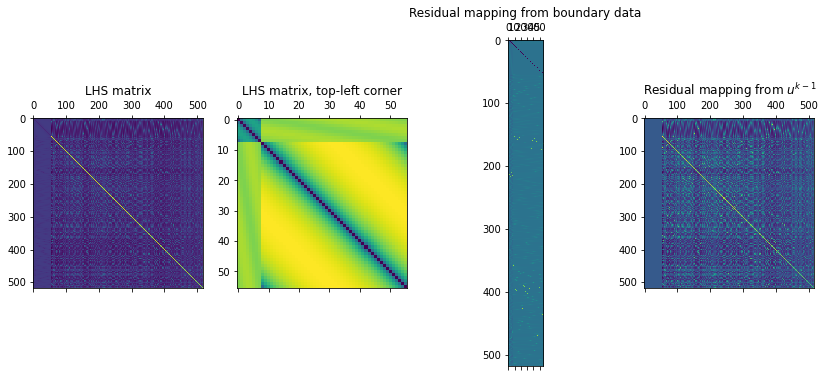

In [5]:
msh_file_name = "annulus_mesh.msh"
DBEM.generate_annulus_mesh_to_file(msh_file_name)
geom = DBEM.read_netlike_mesh(msh_file_name)

ops = DBEM.MeshOperators(geom)
dt = 1e-2
N_t = 100
DBEM.build_explicit_matrices(ops, dt=dt, theta=1.0, show_matrices=True)

In [6]:
# Set up initial condition according to the first eigenfunction of the annulus
u0 = DBEM.generate_annulus_IC(ops, a, b)
# Set up boundary condition
u_bdry = DBEM.generate_dirichlet_BC(ops, val=1)
# Compute time-dependent solution by timestepping
dudn, u_interior = DBEM.time_dependent_solve(ops, u0, u_bdry, dt, N_t, theta=1.0)

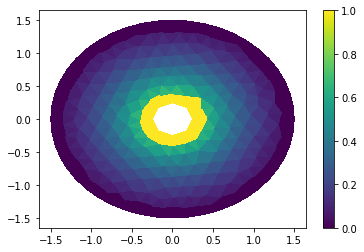

In [7]:
''' Plot solution at last timestep '''
u_show = u_interior[-1,:].copy()
u_show[np.where(geom.is_cell_on_bdry_circ_in)] = 1.0
u_show[np.where(geom.is_cell_on_bdry_circ_out)] = 0.0

triangulation = matplotlib.tri.Triangulation(
  geom.mesh.points[:,0], geom.mesh.points[:,1], geom.tri_indices)
plt.tripcolor(triangulation, u_show.squeeze())
plt.colorbar()

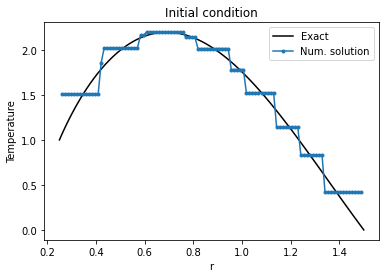

In [8]:
''' Plot initial condition along a line '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(0.25+.01, 1.5-.01, 100)
pick_indices = [int(trifinder(x, 0.0)) for x in probe_line]
u_along_line = u_interior[-1, pick_indices]

u_hist_along_line = u_interior.squeeze()[:,pick_indices]

u0_int = u0[ops.n_bdry_node:]
plt.plot(r_test_range, DBEM.annulus_steady_term(r_test_range, 0, a, b)
                       + DBEM.annulus_series_term(r_test_range, 0, a, b, 1),
                      'k-', label="Exact")
plt.plot(probe_line, u0_int[pick_indices], '.-', label="Num. solution")
plt.title("Initial condition")
plt.xlabel("r")
plt.ylabel("Temperature")
plt.legend()

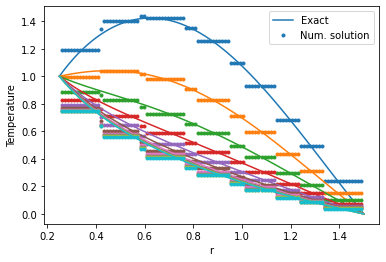

In [9]:
''' Plot solution at different times along a line '''
t_plot_vec = 10*(dt + dt*np.arange(0,10))
for i, t in enumerate(t_plot_vec):
  # Compute constructed analytic solution
  r_test_range = np.linspace(a, b, 100)
  T_test = (DBEM.annulus_steady_term(r_test_range, t, a, b)
            + DBEM.annulus_series_term(r_test_range, t, a, b, 1))
  # Plot analytic
  line, = plt.plot(r_test_range, T_test, '-', label="Exact")
  # Plot numerical
  plt.plot(probe_line, u_hist_along_line[10*i+9,:], '.', color=line.get_color(),
           label="Num. solution")

plt.xlabel("r")
plt.ylabel("Temperature")
plt.legend(["Exact", "Num. solution"])

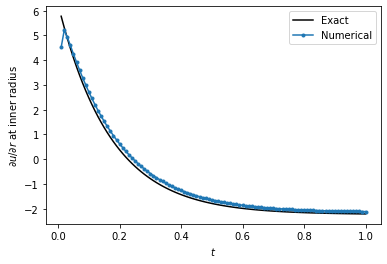

In [10]:
''' Compare normal gradient value at boundary '''

# Extract gradients at inner circle boundary
dudn_interior = dudn.squeeze()[:,:geom.n_circ_in_elts]
# Compute t range
t_plot_range = (dt + dt*np.arange(0, N_t))

# Compute exact du/dr for given initial condition
dudr_exact = (DBEM.annulus_steady_ddr(a, 0.0, a, b, dim=2)
  + DBEM.annulus_series_ddr(a, t_plot_range, a, b, 1, dim=2, alpha=1.0))
# Exact du/dr
plt.plot(t_plot_range, dudr_exact, 'k-', label="Exact")
# Numerical -du/dn (outward normal is in -r direction)
plt.plot(t_plot_range, -dudn_interior.mean(axis=1), '.-', label="Numerical")
plt.xlabel("$t$")
plt.ylabel("$\partial u/\partial r$ at inner radius")
plt.legend()

Chamber network

In [11]:
network_mesh_name = "network_mesh.msh"
N_chambers = 4
chamber_radius = 0.2
outer_radius = 5.0

chamber_centers = DBEM.generate_network_mesh_to_file(
  network_mesh_name, dx=0.2, seed=6,
  chamber_radius=0.2,
  outer_radius=5,
  N_chambers=N_chambers)

geom = DBEM.read_netlike_mesh(network_mesh_name)
ops = DBEM.MeshOperators(geom)
u0 = DBEM.generate_network_IC(ops, 0.1, gradient=25)
u_bdry = DBEM.generate_network_BC(ops)

dt = 1e-1
t_range = (dt + dt*np.arange(0,N_t))

In [12]:
dudn, u_interior = DBEM.time_dependent_solve(ops, u0, u_bdry, dt, N_t, theta=1.0)

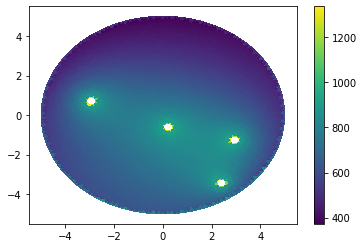

In [13]:
# Generate color plot
triangulation = matplotlib.tri.Triangulation(
  geom.mesh.points[:,0], geom.mesh.points[:,1], geom.tri_indices)
plt.tripcolor(triangulation, u_interior[-1,:].squeeze())
plt.colorbar()

Dots are values of (du/dn, z) for the boundary element centers
du/dn is the normal derivative (normal is positive pointing inside the chamber)


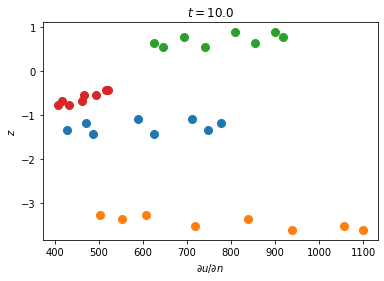

In [14]:
''' Plot temperature gradient at each chamber boundary at last time index '''
dudn_chambers = dudn[-1,:geom.n_circ_in_elts].squeeze()
dudn_outer = dudn[-1,geom.n_circ_in_elts:].squeeze()

chamber_global_indices = DBEM.get_chamber_global_indices(geom, N_chambers)

# Extract depth of points on chamber boundary
depth_chamber_points = geom.bdry_edge_centers[:geom.n_circ_in_elts,1]
for i in range(N_chambers):
  plt.plot(dudn_chambers[chamber_global_indices[i]],
           depth_chamber_points[chamber_global_indices[i]], '.', markersize=16)
plt.xlabel("$\partial u/\partial n$")
plt.ylabel("$z$")
plt.title(f"$t = {t_range[-1]}$")
print("Dots are values of (du/dn, z) for the boundary element centers")
print("du/dn is the normal derivative (normal is positive pointing inside the chamber)")

Text(0, 0.5, '$\\partial u/\\partial r$, mean all chambers')

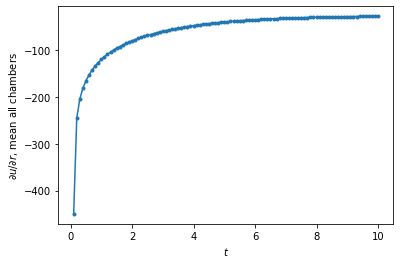

In [15]:
''' Compare normal gradient value at boundary '''
plt.plot(t_range, -dudn.squeeze().mean(axis=1), '.-')
plt.xlabel("$t$")
plt.ylabel("$\partial u/\partial r$, mean all chambers")

Text(0.5, 1.0, 'Temperature along line x = 0')

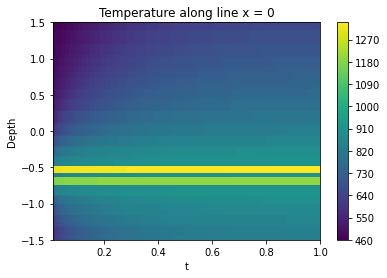

In [ ]:
''' Plot along the center line x = 0 '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(-b, b, 1000)
pick_indices = np.array([int(trifinder(0.0, y)) for y in probe_line])

u_hist_along_line = np.where(pick_indices >= 0,
                             u_interior.squeeze()[:,pick_indices],
                             np.nan)

plt.contourf(t_plot_range, probe_line, u_hist_along_line.T, levels=100)
plt.colorbar()
plt.ylabel("Depth")
plt.xlabel("t")
plt.title("Temperature along line x = 0")

Text(0, 0.5, 'Temperature')

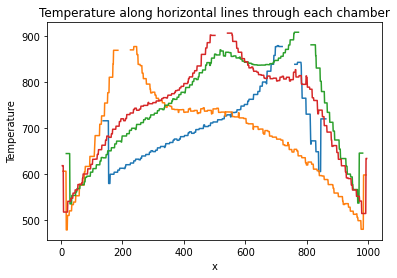

In [ ]:
# Probe for depth-dependent temperature profiles

y_min = chamber_centers[:,1].min()
y_max = chamber_centers[:,1].max()
y_1 = chamber_centers[0,1]
y_2 = chamber_centers[3,1]

''' Plot along the center line x = 0 '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(-outer_radius, outer_radius, 1000)
pick_indices_min = np.array([int(trifinder(x, y_min)) for x in probe_line])
pick_indices_m1 = np.array([int(trifinder(x, y_1)) for x in probe_line])
pick_indices_m2 = np.array([int(trifinder(x, y_2)) for x in probe_line])
pick_indices_max = np.array([int(trifinder(x, y_max)) for x in probe_line])

u_int_last = u_interior.squeeze()
u_last_min = np.where(pick_indices_min >= 0, u_int_last[:,pick_indices_min], np.nan)
u_last_m1 = np.where(pick_indices_m1 >= 0, u_int_last[:,pick_indices_m1], np.nan)
u_last_m2 = np.where(pick_indices_m2 >= 0, u_int_last[:,pick_indices_m2], np.nan)
u_last_max = np.where(pick_indices_max >= 0, u_int_last[:,pick_indices_max], np.nan)

plt.plot(u_last_min[-1,:])
plt.plot(u_last_max[-1,:])
plt.plot(u_last_m1[-1,:])
plt.plot(u_last_m2[-1,:])
plt.title("Temperature along horizontal lines through each chamber")
plt.xlabel("x")
plt.ylabel("Temperature")


Sample shear viscosity in a horizontal line through highest chamber


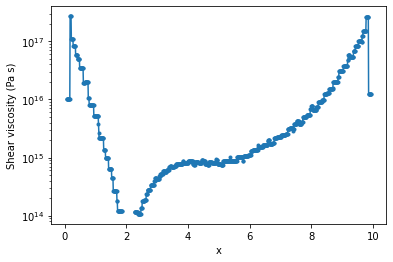

In [18]:
# Shear viscosity from Degruyter and Huber with constant geothermal gradient

# Molar gas constant (J/(mol K))
R = 8.31
# Viscosity prefactor (Pa s)
A = 4.25e7
# Creep activation energy (J/mol)
Ea = 141e3
# Creep activation temperature (K)
Ta = Ea / R

def visc_crust(T):
  ''' Arrhenius viscosity '''
  return A * np.exp(Ta / T)

''' Plot viscosity along horizontal probe line '''

plt.semilogy(probe_line - probe_line.min(),
             visc_crust(u_last_max[-1,:]+273.15), '.-')
plt.xlabel("x")
plt.ylabel("Shear viscosity (Pa s)")
print("Sample shear viscosity in a horizontal line through highest chamber")